In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

for pkg in [pm, np, pd, sns, az]:
    print(f"{pkg.__name__} v{pkg.__version__}")

%config InlineBackend.figure_format = 'retina'

pymc v5.21.1
numpy v2.2.3
pandas v2.2.3
seaborn v0.13.2
arviz v0.21.0


In [2]:
muts_all = pd.read_csv("mut_counts_all.tsv", sep="\t")
sample_metadata = pd.read_csv("lcm_all_metadata_wVAF_wSensitivity.tsv", sep="\t")

In [3]:
# Suppress SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

# Filter samples based on Cell_type and Tissue
duct_samples = sample_metadata[sample_metadata["Cell_type"] == "Duct"]["Sample_ID"]
acini_samples = sample_metadata[sample_metadata["Cell_type"] == "Acinus"]["Sample_ID"]
lymphocyte_samples = sample_metadata[sample_metadata["Tissue"] == "Lymphocyte"][
    "Sample_ID"
]

# Filter metadata for Epithelium tissue
metadata_epi = sample_metadata[sample_metadata["Tissue"] == "Epithelium"]

# Filter mutations for specific samples and conditions
mutations_epi = muts_all[
    (muts_all["Sample"].isin(duct_samples) | muts_all["Sample"].isin(acini_samples))
    & (muts_all["NV"] >= 3)
    & (muts_all["Depth"] >= 4)
]
mutations_epi["Patient"] = mutations_epi["Sample"].str[:7]

# Add Diagnosis column based on Patient
mutations_epi["Diagnosis"] = np.where(
    mutations_epi["Patient"].isin([f"PD427{num}" for num in range(59, 67)]),
    "Non-PSS",
    "PSS",
)

# Add Cell_type column based on Sample
mutations_epi["Cell_type"] = np.where(
    mutations_epi["Sample"].isin(duct_samples), "Duct", "Acinus"
)

In [4]:
# idata = az.from_netcdf("diagnosis_posterior_25031701.nc")

In [5]:
# az.plot_trace(idata, var_names=["VAF"], filter_vars='like', divergences=False)

# plt.tight_layout();

In [6]:
# category = 'Diagnosis'
# # --- Visualization ---

# by_sample, by_category, category_diff = ['VAF by Sample', 'VAF by Diagnosis', 'VAF_PSS - VAF_Non-PSS']
# diagnoses = mutations_epi[category].astype("category").cat.categories

# # 2. Per-Cell-Type Mean VAF
# axs = az.plot_posterior(idata, var_names=[by_category], hdi_prob=0.95, point_estimate="mean", textsize=12, figsize=(6,3), )
# axs[0].set_title(diagnoses[0])
# axs[1].set_title(diagnoses[1])
# axs[0].set_xlabel('VAF')
# axs[1].set_xlabel('VAF')
# plt.suptitle(f"Mean VAF by {category}\nPosterior Distribution (95% HDI)")
# plt.tight_layout()

# # 3. Difference Between Cell Type Mean VAFs
# ax= az.plot_posterior(idata, var_names=[category_diff], hdi_prob=0.95, ref_val=0, textsize=12, figsize=(4,3))
# plt.title(f"Difference in Mean VAF\n({category_diff})\nPosterior Distribution (95% HDI)")
# plt.axvline(0, color='black', linestyle='--')  # Add a reference line at 0
# ax.set_xlabel('VAF Difference')
# plt.tight_layout()

In [7]:
# Create a more detailed, sample-by-sample plot with cell type coloring
def plot_per_sample_vaf(
    idata, data, category="Cell_type", clist=None, hierarchical_sort=True, ax=None
):
    clist = ["C0", "C1"] if clist is None else clist
    # clist = ["#7FC97F", "#BEAED4"] if clist is None else clist

    categories = data[category].astype("category").cat.categories
    cat_by_code = dict(enumerate(categories))
    code_by_cat = {v: k for k, v in cat_by_code.items()}
    samples_by_code = dict(enumerate(data["Sample"].astype("category").cat.categories))
    code_by_sample = {v: k for k, v in samples_by_code.items()}
    hdi_vaf = az.hdi(idata.posterior["VAF by Sample"].values, hdi_prob=0.95)

    sample_vafs = (
        idata.posterior["VAF by Sample"]
        .mean(dim=["chain", "draw"])
        .to_dataframe()
        .reset_index()
        .rename(columns={"VAF by Sample": "Mean VAF", "VAF by Sample_dim_0": "Sample"})
    )
    sample_vafs["hdi_lower"] = hdi_vaf[:, 0]
    sample_vafs["hdi_upper"] = hdi_vaf[:, 1]
    sample_vafs.Sample = sample_vafs.Sample.map(samples_by_code)
    sample_vafs = sample_vafs.merge(
        mutations_epi[["Sample", category]].drop_duplicates(), on="Sample", how="left"
    )
    if hierarchical_sort:
        sort_by = [category, "Mean VAF"]
    else:
        sort_by = ["Mean VAF"]

    sample_vafs = sample_vafs.sort_values(by=sort_by, ascending=False).reset_index(
        drop=True
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))

    for i, row in sample_vafs.iterrows():
        color = clist[code_by_cat[row[category]]]
        ax.hlines(i, row.hdi_lower, row.hdi_upper, color=color, alpha=0.6, linewidth=1)
        ax.plot(row["Mean VAF"], i, "o", color=color, markersize=2)

    ax.set_ylabel("Sample")
    ax.set_xlabel("VAF")
    ax.set_title("Per-Sample Mean VAF\nPosterior Estimate (with 95% HDI)")
    ax.set_yticks([])

    category_vafs = (
        idata.posterior[f"VAF by {category}"].mean(dim=["chain", "draw"]).values
    )
    l1 = ax.axvline(category_vafs[0], color="k", linestyle="-", label=categories[0])
    l2 = ax.axvline(category_vafs[1], color="k", linestyle="--", label=categories[1])

    # Create a legend
    legend_elements = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=categories[0],
            markerfacecolor=clist[0],
            markersize=8,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=categories[1],
            markerfacecolor=clist[1],
            markersize=8,
        ),
        l1,
        l2,
    ]

    ax.legend(handles=legend_elements)
    plt.tight_layout()
    return ax


# plot_per_sample_vaf(idata, mutations_epi, category)

In [9]:
cell_type_colors = ("#7FC97F", "#BEAED4")
cell_type_labels = ("Acini", "Ducts")
diagnosis_colors = ("#377EB8", "#E42A1C")
diagnosis_labels = ("Non-PSS", "PSS")

diagnosis_idata = az.from_netcdf("Diagnosis_posterior_25092901.nc")
print(len(diagnosis_idata.posterior.draw) * len(diagnosis_idata.posterior.chain))

non_pss_dist = (
    diagnosis_idata.posterior["VAF by Diagnosis"]
    .sel(**{"VAF by Diagnosis_dim_0": 0})
    .values.flatten()
)
pss_dist = (
    diagnosis_idata.posterior["VAF by Diagnosis"]
    .sel(**{"VAF by Diagnosis_dim_0": 1})
    .values.flatten()
)
diagnosis_diff_dist = diagnosis_idata.posterior[
    "VAF_Sjogrens - VAF_Normal"
].values.flatten()

cell_type_idata = az.from_netcdf("Cell_type_posterior_25092901.nc")
print(len(cell_type_idata.posterior.draw) * len(cell_type_idata.posterior.chain))

acini_dist = (
    cell_type_idata.posterior["VAF by Cell_type"]
    .sel(**{"VAF by Cell_type_dim_0": 0})
    .values.flatten()
)
ducts_dist = (
    cell_type_idata.posterior["VAF by Cell_type"]
    .sel(**{"VAF by Cell_type_dim_0": 1})
    .values.flatten()
)
cell_type_diff_dist = cell_type_idata.posterior[
    "VAF_Duct - VAF_Acinus"
].values.flatten()

10000
10000


In [10]:
az.summary(
    diagnosis_idata,
    hdi_prob=0.95,
    var_names=["VAF by Diagnosis", "VAF_Sjogrens - VAF_Normal"],
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
VAF by Diagnosis[0],0.298,0.007,0.285,0.311,0.0,0.0,11100.0,6330.0,1.0
VAF by Diagnosis[1],0.292,0.005,0.283,0.302,0.0,0.0,10260.0,6426.0,1.0
VAF_Sjogrens - VAF_Normal,-0.006,0.008,-0.022,0.010,0.0,0.0,10813.0,7764.0,1.0


In [11]:
az.summary(
    cell_type_idata,
    hdi_prob=0.95,
    var_names=["VAF by Cell_type", "VAF_Duct - VAF_Acinus"],
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
VAF by Cell_type[0],0.326,0.007,0.312,0.339,0.0,0.0,10146.0,6416.0,1.0
VAF by Cell_type[1],0.278,0.005,0.269,0.287,0.0,0.0,10063.0,6202.0,1.0
VAF_Duct - VAF_Acinus,-0.048,0.008,-0.064,-0.032,0.0,0.0,10262.0,7153.0,1.0


Diagnosis: Diff mean = 0.0056; p(Diff !> 0) = 0.2504; min p = 0.0001
Cell_type: Diff mean = 0.0478; p(Diff !> 0) = 0.0000; min p = 0.0001


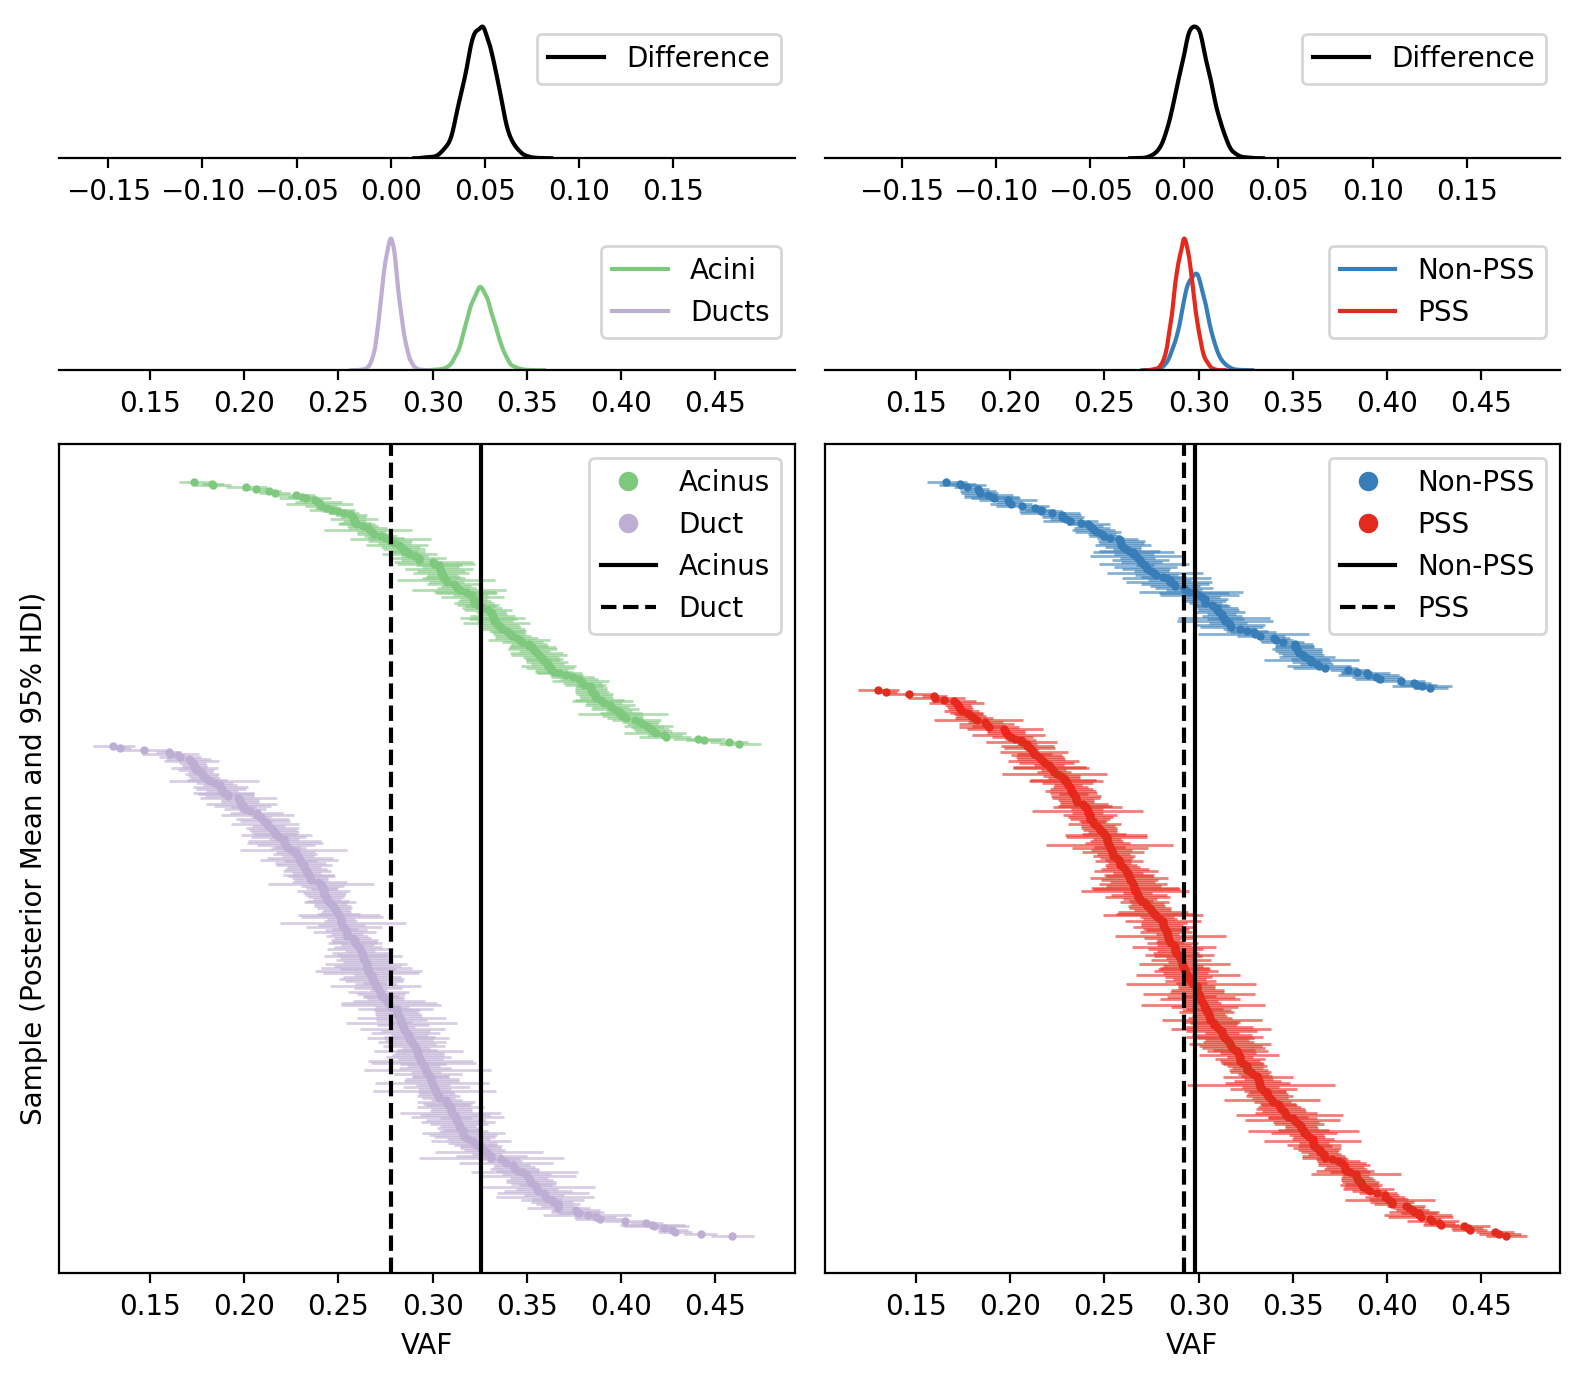

In [ ]:
def plot_column(axs, idata, category, cat_dists, cat_colors, cat_labels, diff_dist):
    diff_sign = np.sign(diff_dist.mean())
    print(
        f"{category}: Diff mean = {diff_sign * diff_dist.mean():.4f}; p(Diff !> 0) = {1 - (diff_sign * diff_dist > 0).mean():.4f}; min p = {1 / diff_dist.size:.4f}"
    )
    sns.kdeplot(diff_sign * diff_dist, ax=axs[0], color="k", label="Difference")
    axs[0].legend()
    # axs[0].set_xlabel('Difference')
    # axs[0].set_title(f"Difference in Mean /VAF\nPosterior Distribution")

    sns.kdeplot(cat_dists[0], ax=axs[1], label=cat_labels[0], color=cat_colors[0])
    sns.kdeplot(cat_dists[1], ax=axs[1], label=cat_labels[1], color=cat_colors[1])
    axs[1].legend()
    # axs[1].set_xlabel('VAF')
    # axs[1].set_title(f"Mean VAF by Diagnosis\nPosterior Distribution")

    plot_per_sample_vaf(idata, mutations_epi, category, clist=cat_colors, ax=axs[2])

    xl = axs[2].get_xlim()
    axs[1].set_xlim(xl)

    # midpt = np.mean([cat_dists[0].mean(), cat_dists[1].mean()])
    midpt = np.mean(xl) - min(cat_dists[0].mean(), cat_dists[1].mean())
    axs[0].set_xlim((midpt - np.diff(xl) / 2, midpt + np.diff(xl) / 2))

    for ax in [axs[0], axs[1]]:
        for spine in ax.spines.values():
            if spine.spine_type != "bottom":
                spine.set_visible(False)

        ax.set_ylabel("")
        ax.set_yticks([])

    axs[0].set_xticks([-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15])
    axs[1].set_xticks([0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45])
    axs[2].set_xticks([0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45])

    # axs[0].set_ylabel('Difference in VAF by Diagnosis\nPosterior Distribution')
    # axs[1].set_ylabel('VAF by Diagnosis\nPosterior Distribution')
    axs[2].set_ylabel("Sample (Posterior Mean and 95% HDI)")
    axs[2].set_title("")


fig, axs = plt.subplots(
    3, 2, figsize=(8, 7), gridspec_kw={"height_ratios": [1, 1, 6]}, squeeze=False
)
plot_column(
    axs[:, 1],
    diagnosis_idata,
    "Diagnosis",
    cat_dists=(non_pss_dist, pss_dist),
    cat_colors=diagnosis_colors,
    cat_labels=diagnosis_labels,
    diff_dist=diagnosis_diff_dist,
)

plot_column(
    axs[:, 0],
    cell_type_idata,
    "Cell_type",
    cat_dists=(acini_dist, ducts_dist),
    cat_colors=cell_type_colors,
    cat_labels=cell_type_labels,
    diff_dist=cell_type_diff_dist,
)

axs[2, 1].set_ylabel("")

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)

plt.savefig("side_by_side_comparison_251001.png", dpi=300)
plt.savefig("side_by_side_comparison_251001.pdf")